# XGBoost 回归与可解释性分析

## 1. 数据准备、建模与评估


### 1.0 全局配置
配置程序主要参数，包括数据来源、模型来源
必须允许该程序块

In [21]:
# ==================== 全局配置（优先修改这里） ====================
from pathlib import Path
import re
import pandas as pd

# 项目程序根目录：自动获取
PROJECT_ROOT = Path.cwd()

# 数据文件路径 与 目标列、需排除列
DATA_PATH = PROJECT_ROOT / "Example" / "ALL_data_analysis" / "ALL_exp._results.csv"
TARGET_COLUMN = "EGT titer (mg/L)"
ANALYSIS_ROUND = ["Round 1","Round 2","Round 3"]# ,"Round 4"
DROP_COLUMNS = ["Round","Medium material cost (CNY/L)","EGT efficiency cost (mg /CNY)" ]


# 设定并创建输出目录：同名文件会被新结果覆盖，
OUTPUT_ROOT = PROJECT_ROOT / "Example" / "ALL_data_analysis" / "SHAP_outputs"
MODELING_OUTPUT_DIR = OUTPUT_ROOT / "01_modeling"
SHAP_MAIN_OUTPUT_DIR = OUTPUT_ROOT / "02_shap_main"
SHAP_INTERACTION_OUTPUT_DIR = OUTPUT_ROOT / "03_shap_interaction"


for output_dir in (
    MODELING_OUTPUT_DIR,
    SHAP_MAIN_OUTPUT_DIR,
    SHAP_INTERACTION_OUTPUT_DIR,
):
    output_dir.mkdir(parents=True, exist_ok=True)

# 随机种子设定
RANDOM_SEED = 42


# 已训练模型配置读取：默认模型存在输出目录下
LOAD_EXISTING_MODEL = False  # True 表示加载已训练模型，False 表示重新训练模型
MODEL_PATH = OUTPUT_ROOT / "01_modeling" / "best_xgb_titer.joblib" 


# -------数据读取与化学式适配---------
# 读取训练数据集
data = pd.read_csv(DATA_PATH)
data = data[data["Round"].isin(ANALYSIS_ROUND)]
data = data.drop(columns=DROP_COLUMNS)

# X 为特征，y 为标签
X = data.drop(columns=[TARGET_COLUMN])
y = data[TARGET_COLUMN]
rawcolumns = X.columns.values

# 为输入特征创建化学式标签映射，便于绘图时显示
feature_label_map = {
    '(NH4)2SO4 (g/L)': r'$\mathrm{(NH_4)_2SO_4}$',
    'Triton X-100 (g/L)': r'$\mathrm{Triton\ X\text{-}100}$', 
    'Glycine (g/L)': r'$\mathrm{Glycine}$',
    'CSL-P (g/L)':r'$\mathrm{CSL\text{-}P}$',
    'NaCl (g/L)': r'$\mathrm{NaCl}$',
    'K2HPO4 (g/L)': r'$\mathrm{K_2HPO_4}$',
    'Tryptone (g/L)': r'$\mathrm{Tryptone}$',
    'YE (g/L)': r'$\mathrm{YE}$',
    'Methionine (g/L)':r'$\mathrm{Methionine}$',
    'Cysteine (g/L)':r'$\mathrm{Cysteine}$',
    'NH4OAc (g/L)': r'$\mathrm{NH_4OAc}$',
    'Glycerol (g/L)': r'$\mathrm{Glycerol}$',
    'Na2S2O3 (g/L)':r'$\mathrm{Na_2S_2O_3}$',
    'ZnSO4·7H2O (g/L)': r'$\mathrm{ZnSO_4}\!\cdot\!\mathrm{7H_2O}$',
    'MgSO4·7H2O (g/L)': r'$\mathrm{MgSO_4}\!\cdot\!\mathrm{7H_2O}$',
    'FAC (g/L)': r'$\mathrm{FAC}$'
    }


columns = [
    feature_label_map.get(name, name)
    for name in rawcolumns
]

def safe_filename(value):
    """将特征名转换为适合 Windows 文件名的文本。"""
    return re.sub(r'[<>:"/\|?*]+', "_", str(value)).strip().replace(" ", "_")


print(f"项目目录: {PROJECT_ROOT}")
print(f"数据文件: {DATA_PATH}")
print(f"输出目录: {OUTPUT_ROOT}")


项目目录: c:\Users\Liaoyt\Desktop\Ai_medium\github
数据文件: c:\Users\Liaoyt\Desktop\Ai_medium\github\Example\ALL_data_analysis\ALL_exp._results.csv
输出目录: c:\Users\Liaoyt\Desktop\Ai_medium\github\Example\ALL_data_analysis\SHAP_outputs


### 1.1 数据读取、模型调参与特征重要性

读取数据，划分训练集与测试集，并通过 10 折交叉验证和网格搜索确定 XGBoost 回归模型的最优超参数。随后计算测试集 MSE，导出最优参数、特征重要性表及特征重要性图。

调参完成，最佳模型已保存至: c:\Users\Liaoyt\Desktop\Ai_medium\github\Example\ALL_data_analysis\SHAP_outputs\01_modeling\best_xgb_titer.joblib
MSE: 1647.8287821555411
sort_importance_and_feature: [(np.float32(0.7142245), 'NH4OAc (g/L)'), (np.float32(0.16864358), '(NH4)2SO4 (g/L)'), (np.float32(0.031650957), 'Glycine (g/L)'), (np.float32(0.02909558), 'Glycerol (g/L)'), (np.float32(0.013708634), 'Triton X-100 (g/L)'), (np.float32(0.009517378), 'YE (g/L)'), (np.float32(0.0044492427), 'Methionine (g/L)'), (np.float32(0.0043812827), 'Cysteine (g/L)'), (np.float32(0.0039714305), 'ZnSO4·7H2O (g/L)'), (np.float32(0.0032691932), 'K2HPO4 (g/L)'), (np.float32(0.003081313), 'CSL-P (g/L)'), (np.float32(0.0028539367), 'NaCl (g/L)'), (np.float32(0.002846834), 'MgSO4·7H2O (g/L)'), (np.float32(0.0028065105), 'FAC (g/L)'), (np.float32(0.0027969484), 'Tryptone (g/L)'), (np.float32(0.0027027042), 'Na2S2O3 (g/L)')]


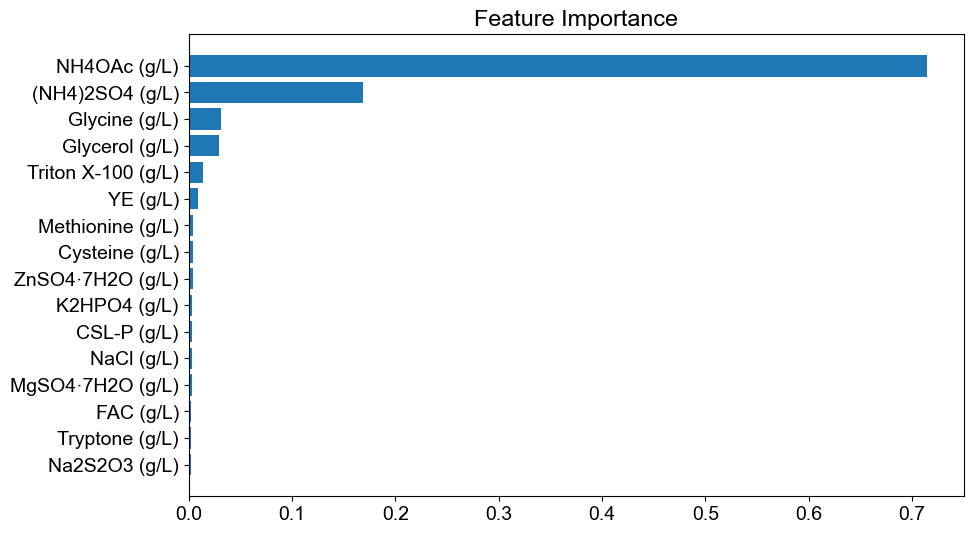

In [22]:
import pandas as pd
import numpy as np
import joblib
import xgboost as xgb
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from xgboost import plot_importance
from sklearn.inspection import PartialDependenceDisplay, partial_dependence
import seaborn as sns
from scipy.interpolate import splev, splrep


# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_SEED,
)

# 超参数随机搜索
model = xgb.XGBRegressor(
    objective="reg:squarederror",
    random_state=RANDOM_SEED,
)
param_grid = {
    "learning_rate": [0.01, 0.03, 0.1, 0.3],
    "colsample_bytree": [0.6, 0.8, 0.9, 1.0],
    "subsample": [0.6, 0.8, 0.9, 1.0],
    "max_depth": [2, 3, 4, 6 , 8],
    "n_estimators": [10, 20,  40, 60, 80, 100, 300, 500],
    "reg_lambda": [1, 1.5, 2],
    "gamma": [0, 0.1, 0.4, 0.6],
    "min_child_weight": [1, 2, 4]
    }   

grid_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    n_iter=200,     # 设置为 200 次随机搜索
    random_state=RANDOM_SEED,
)


if LOAD_EXISTING_MODEL and MODEL_PATH.exists():

    best_model = joblib.load(MODEL_PATH)
    model_params = best_model.get_params()
    print(f'已读取已有模型: {MODEL_PATH}')
else:
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_
    joblib.dump(best_model, MODEL_PATH)
    print(f'调参完成，最佳模型已保存至: {MODEL_PATH}')



# 测试集预测与 MSE
y_pred = best_model.predict(X_test)
mse = np.mean((y_pred - y_test) ** 2)
print('MSE:', mse)


# 特征重要性
importance = best_model.feature_importances_
sort_importance_and_feature = list(sorted(zip(importance, X.columns), reverse=True))
print('sort_importance_and_feature:', sort_importance_and_feature)
plt.figure(figsize=(10, 6))
plt.barh([x[1] for x in sort_importance_and_feature], [x[0] for x in sort_importance_and_feature])
plt.title('Feature Importance')
plt.gca().invert_yaxis()
plt.savefig(MODELING_OUTPUT_DIR / 'feature_importance.png')
plt.show()

pd.DataFrame(
    sort_importance_and_feature,
    columns=['importance', 'feature'],
).to_csv(MODELING_OUTPUT_DIR / 'importance.csv', index=False)


### 1.2 模型性能评估

分别在训练集和测试集上计算 R²、MSE、RMSE、MAE 与 MAPE，用于比较模型的拟合能力和泛化表现。

In [23]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
y_pred_train = best_model.predict(X_train)
y_pred_test = best_model.predict(X_test)

# 计算训练集的评价指标
r2_score_train = best_model.score(X_train, y_train)
mse_train = mean_squared_error(y_train, y_pred_train)
rmse_train = np.sqrt(mse_train)  # 计算RMSE
mae_train = mean_absolute_error(y_train, y_pred_train)
mape_train = np.mean(np.abs((y_train - y_pred_train) / y_train)) * 100

# 计算测试集的评价指标
r2_score_test = best_model.score(X_test, y_test)
mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test)  # 计算RMSE
mae_test = mean_absolute_error(y_test, y_pred_test)
mape_test = np.mean(np.abs((y_test - y_pred_test) / y_test)) * 100

# 打印所有评价指标
print("训练集评价指标：")
print("R2:", r2_score_train)
print("MSE:", mse_train)
print("RMSE:", rmse_train)
print("MAE:", mae_train)
print("MAPE:", mape_train, "%")

print("\n测试集评价指标：")
print("R2:", r2_score_test)
print("MSE:", mse_test)
print("RMSE:", rmse_test)
print("MAE:", mae_test)
print("MAPE:", mape_test, "%")

metrics_df = pd.DataFrame({
    'dataset': ['train', 'test'],
    'R2': [r2_score_train, r2_score_test],
    'MSE': [mse_train, mse_test],
    'RMSE': [rmse_train, rmse_test],
    'MAE': [mae_train, mae_test],
    'MAPE_percent': [mape_train, mape_test],
})
metrics_df.to_csv(MODELING_OUTPUT_DIR / 'model_metrics.csv', index=False)


训练集评价指标：
R2: 0.9999744276530722
MSE: 0.2645348575413056
RMSE: 0.514329522331069
MAE: 0.3513709882136283
MAPE: inf %

测试集评价指标：
R2: 0.7928537667263513
MSE: 1647.8287821555411
RMSE: 40.59345738115369
MAE: 25.18055548784929
MAPE: inf %


### 1.3 特征相关性分析

计算全部变量的相关系数矩阵，并绘制仅显示上三角区域的相关性热力图，以观察特征之间及其与目标变量之间的线性相关关系。

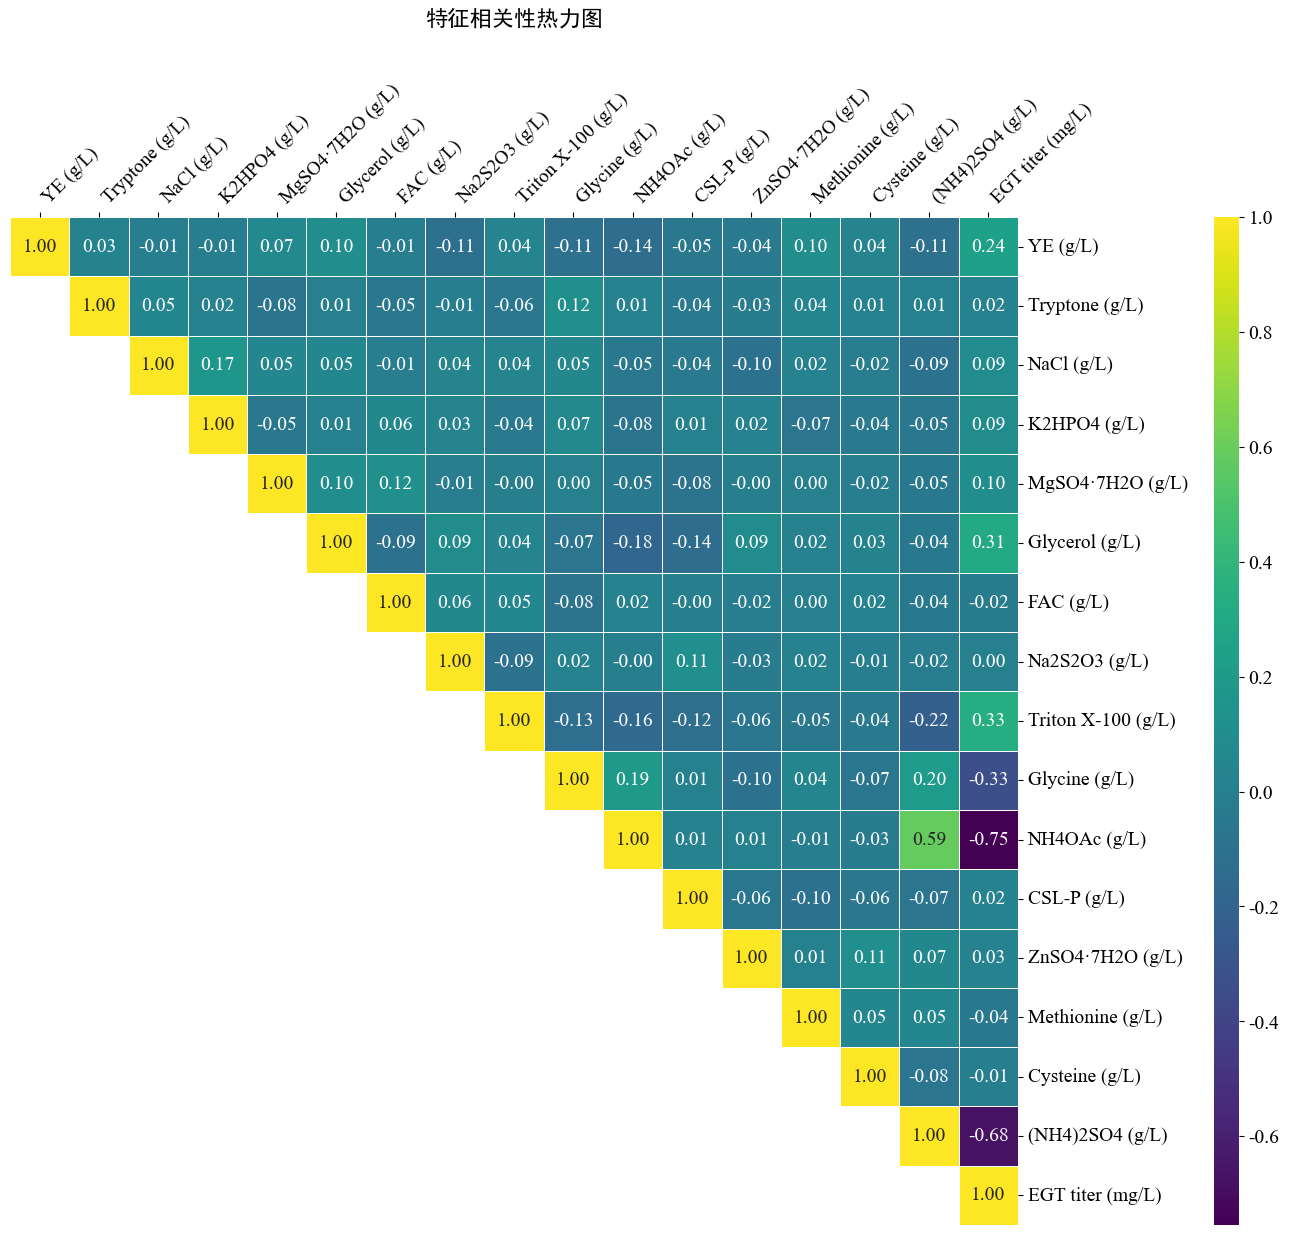

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- 设置全局字体 ---
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['font.family'] = ['Times New Roman', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = 14
# --------------------------
corr_matrix=data.corr()

# 增大图形宽度，为右侧颜色条和标签留出更多空间
plt.figure(figsize=(16, 12))

# --- 自定义颜色映射 ---
from matplotlib.colors import LinearSegmentedColormap
custom_cmap = plt.cm.viridis
# ----------------------------------------

# --- 创建上三角mask（遮挡下三角） ---
mask = np.tril(np.ones_like(corr_matrix, dtype=bool), k=-1)  # k=0包含对角线，k=-1保留对角线

# --- 绘制上三角热力图 ---
ax = sns.heatmap(
    corr_matrix,
    annot=True,
    cmap=custom_cmap,
    fmt='.2f',
    annot_kws={"size": 14},
    mask=mask,  # 遮挡下三角，只显示上三角
    # 核心：调整颜色条位置和间距
    cbar_kws={
        "shrink": 1,        # 缩小颜色条高度
        "location": "right",  # 颜色条在右侧
        "pad": 0,          # 颜色条与热力图的间距（增大此值=颜色条右移）
        "aspect": 40,         # 颜色条的长宽比（越大越细长）
        "anchor": (1, 0)  # 颜色条锚点，进一步右移
    },
    square=True,
    linewidths=0.5,
    linecolor='white',
    # 热力图内边距，避免内容太靠边
    yticklabels=True,
    xticklabels=True
)

# --- 调整标签位置 + 解决重叠 ---
# 1. X轴刻度标签移到顶部
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
# 2. Y轴刻度标签移到右侧
ax.yaxis.tick_right()
ax.yaxis.set_label_position('right')

# --- 优化Y轴右侧标签 ---
y_ticks = ax.get_yticklabels()
ax.set_yticklabels(
    y_ticks,
    rotation=0,
    ha='left',         # 左对齐，远离热力图
    va='center',       # 垂直居中
    fontsize=14,
    # position=(1, 0) # 水平偏移（1.03=向右偏移3%）
)

# --- 优化X轴顶部标签 ---
x_ticks = ax.get_xticklabels()
ax.set_xticklabels(
    x_ticks,
    rotation=45,
    ha='left',
    va='bottom',
    fontsize=14
)

# --- 调整整体布局，预留右侧空间 ---
plt.subplots_adjust(
    left=0.08,   # 左侧边距
    right=1,  # 右侧边距（减小此值=预留更多右侧空间）
    top=0.92,    # 顶部边距
    bottom=0.08  # 底部边距
)

# --- 标题和最终调整 ---
plt.title('特征相关性热力图', fontsize=16, pad=40)
# # 强制调整布局，避免裁剪
# plt.tight_layout(rect=[0.05, 0.05, 0.95, 0.95])

# 保存图片（高分辨率）
plt.savefig(
    MODELING_OUTPUT_DIR / '特征相关性热力图.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white'  # 背景白色
)
plt.show()

### 1.4 真实值与预测值对比

定义回归结果可视化函数，在同一坐标系中展示训练集和测试集的真实值与预测值，并以理想预测线及 R²、RMSE 指标辅助判断模型表现。

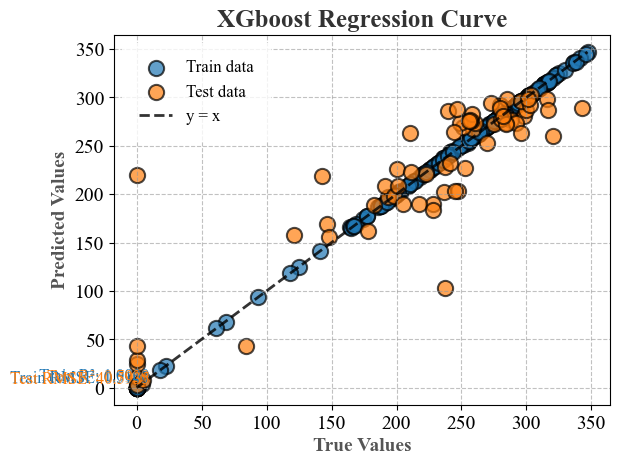

In [25]:



def plot_regression_curve(model, X_train, X_test, y_train, y_test, model_name):
    # Make predictions on training and testing data
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Calculate R², RMSE, and MAE
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

    # Plot regression curve (with circles for data points)
    plt.scatter(y_train, y_train_pred, label="Train data", alpha=0.7, s=120, facecolors='#1f77b4', edgecolors='black', linewidth=1.5, marker='o')  # Train data
    plt.scatter(y_test, y_test_pred, label="Test data", alpha=0.7, s=120, facecolors='#ff7f0e', edgecolors='black', linewidth=1.5, marker='o')   # Test data

    # Plot ideal y=x line
    plt.plot([min(y_train.min(), y_test.min()), max(y_train.max(), y_test.max())],
            [min(y_train.min(), y_test.min()), max(y_train.max(), y_test.max())],
            'k--', label="y = x", alpha=0.8, linewidth=2)

    # Set title and labels
    plt.title(f"{model_name} Regression Curve", fontsize=18, fontweight='bold', color='#333333')
    plt.xlabel("True Values", fontsize=14, fontweight='bold', color='#555555')
    plt.ylabel("Predicted Values", fontsize=14, fontweight='bold', color='#555555') 

    # Display R², RMSE in the bottom right corner
    plt.text(10, 3, f"Train R²: {r2_train:.4f}", fontsize=12, verticalalignment='bottom', horizontalalignment='right', color='#1f77b4')
    plt.text(10, 2, f"Test R²: {r2_test:.4f}", fontsize=12, verticalalignment='bottom', horizontalalignment='right', color='#ff7f0e')
    plt.text(10, 1, f"Train RMSE: {rmse_train:.4f}", fontsize=12, verticalalignment='bottom', horizontalalignment='right', color='#1f77b4')
    plt.text(10, 0, f"Test RMSE: {rmse_test:.4f}", fontsize=12, verticalalignment='bottom', horizontalalignment='right', color='#ff7f0e')

    # Beautify the plot
    plt.legend(loc="upper left", fontsize=12, fancybox=True, framealpha=0.8, facecolor='white', edgecolor='white', borderpad=1)
    plt.grid(True, which='both', linestyle='--', linewidth=0.8, alpha=0.6, color='#999999')

    plt.savefig(MODELING_OUTPUT_DIR / f'{safe_filename(model_name)}_regression_curve.png', bbox_inches='tight')
    plt.show()

plot_regression_curve(best_model, X_train, X_test, y_train, y_test, 'XGboost')


### 1.5 学习曲线

绘制模型的学习曲线，观察训练样本规模变化对训练与交叉验证性能的影响，为判断欠拟合或过拟合提供依据。

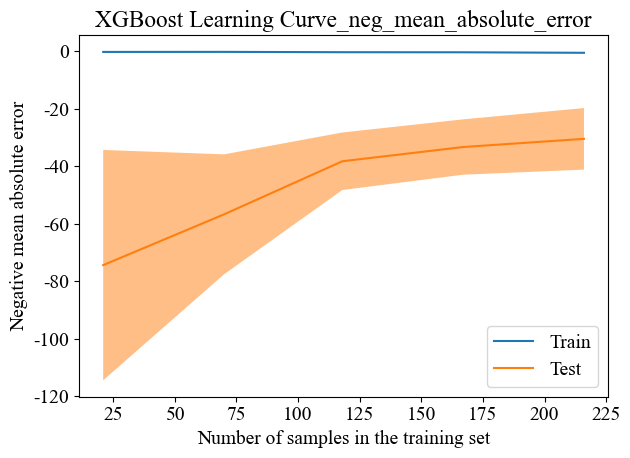

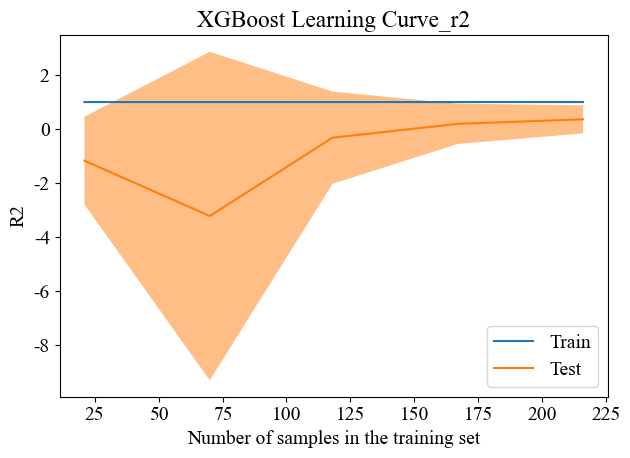

In [26]:
# import scikitplot as skplt

# skplt.estimators.plot_learning_curve(model, X, y)
# plt.show()

from sklearn.model_selection import LearningCurveDisplay
import numpy as np
import matplotlib.pyplot as plt



def plot_learning_curve(estimator, X, y, scoring="neg_mean_absolute_error"):
    """
    Plot the learning curve for a given estimator.
    """
    LearningCurveDisplay.from_estimator(
        estimator,
        X,
        y,
        train_sizes=np.linspace(0.1, 1.0, 5),
        cv=5,
        scoring=scoring,
        n_jobs=-1,
    )

    plt.title("XGBoost Learning Curve_{scoring}".format(scoring=scoring))
    plt.tight_layout()
    plt.savefig(
        MODELING_OUTPUT_DIR / "learning_curve_{scoring}.png".format(scoring=scoring),
        bbox_inches="tight",
    )
    plt.show()

plot_learning_curve(best_model, X, y, scoring="neg_mean_absolute_error")
plot_learning_curve(best_model, X, y, scoring="r2")

## 2. SHAP 主效应分析

### 2.1 计算 SHAP 值

基于训练完成的树模型创建 `TreeExplainer`，并为完整特征数据计算 SHAP 值，作为后续全局与局部解释的基础。

In [27]:
import shap
from statsmodels.nonparametric.smoothers_lowess import lowess
from matplotlib.ticker import MaxNLocator


# shap分析需要对应的模型以及数据集
explainer = shap.TreeExplainer(best_model) 
# 计算 SHAP 值
shap_values = explainer.shap_values(X)


### 2.2 SHAP 蜂群图与全局重要性组合图

将 SHAP 蜂群分布与平均绝对 SHAP 值条形图组合展示，并计算各特征对总重要性的百分比，输出排序结果并保存图像。

In [28]:
import matplotlib.pyplot as plt
import shap
import numpy as np
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.text import Text

# 仅针对 3.2 模块统一设置字体，确保坐标轴、刻度、颜色条和标注均使用 Arial。
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial']

# 绘图的 SVG 输出时，确保文本以文本形式保存，以便后续编辑
plt.rcParams["svg.fonttype"] = "none"

# 创建主图（用来画蜂巢图）
fig, ax1 = plt.subplots(figsize=(10, 8), dpi=1200)

# 计算每个特征的平均SHAP值
mean_shap_values = np.abs(shap_values).mean(0)
total_importance = mean_shap_values.sum()
percentages = (mean_shap_values / total_importance) * 100

# 创建特征名称和对应的数值
feature_importance_data = list(zip(columns, mean_shap_values, percentages))
# 按重要性排序
feature_importance_data.sort(key=lambda x: x[1], reverse=True)

# 绘制蜂巢图
shap.summary_plot(shap_values, X, columns, plot_type="dot", show=False, color_bar=True,cmap='viridis')
plt.gca().set_position([0.2, 0.2, 0.65, 0.65])  # 调整图表位置，留出右侧空间


ax1 = plt.gca()

fig = plt.gcf()  # 获取当前Figure
ax_cbar = fig.axes[-1]  # 获取最后一个轴（颜色条）


# 显式覆盖 SHAP 默认生成的底部横轴标题和颜色条文字。
ax1.set_xlabel(r'$\mathrm{SHAP\ value\ (impact\ on\ predicted\ titer,\ mg/L)}$', fontsize=13)
ax_cbar.set_ylabel(r'$\mathrm{Feature\ value}$', fontsize=12)
ax_cbar.set_yticks(
    ax_cbar.get_yticks(),
    labels=[r'$\mathrm{Low}$', r'$\mathrm{High}$'],
)


# 创建共享 y 轴的另一个图，绘制特征贡献图在顶部x轴
ax2 = ax1.twiny()
shap.summary_plot(shap_values, X, columns, plot_type="bar", show=False,color="#a17fff")
plt.gca().set_position([0.2, 0.2, 0.65, 0.65])  # 调整图表位置，与蜂巢图对齐

# 在顶部 X 轴添加一条横线
y_max = len(columns)
ax2.axhline(y=16, color='black', linestyle='-', linewidth=1)


# 调整透明度
bars = ax2.patches  # 获取所有的柱状图对象
for bar in bars:
    bar.set_alpha(0.2)  # 设置透明度

# 移动顶部的 X 轴，避免与底部 X 轴重叠
ax2.xaxis.set_label_position('top')  # 将标签移动到顶部
ax2.xaxis.tick_top()  # 将刻度也移动到顶部

ax2.set_xlabel(r'$\mathrm{Mean\ absolute\ SHAP\ value}$', fontsize=12)
# 在右侧添加平均SHAP值和百分比文本（按重要性排序）
# 获取当前图中特征的顺序（从上到下）
current_y_labels = [tick.get_text() for tick in ax1.get_yticklabels()]

# 为每个位置添加对应的数值和百分比
for i, feature_name in enumerate(current_y_labels):
    # 找到该特征在排序后数据中的信息
    feature_data = next((item for item in feature_importance_data if item[0] == feature_name), None)
    if feature_data:
        feature, mean_val, percentage = feature_data
        y_pos = i  # 当前特征在图中的y位置
        
        # 分别绘制SHAP值（蓝色）和百分比（红色）
        # 绘制SHAP值（蓝色）
        ax1.text(ax1.get_xlim()[1] * 0.95, y_pos + 0.18, f'{mean_val:.2f}', 
                 verticalalignment='center', fontsize=8, color='blue')
        
        # 绘制百分比（红色）
        ax1.text(ax1.get_xlim()[1] * 0.95, y_pos - 0.18, f'{percentage:.2f}%', 
                 verticalalignment='center', fontsize=8, color='red')


# 设置y轴标签
ax1.set_ylabel(r'$\mathrm{Feature}$', fontsize=12)


plt.grid(False)
plt.tight_layout() 


# 设置ax1的位置
pos = ax1.get_position()
ax1.set_position([
    pos.x0 - 0.06,    # 向左移动
    pos.y0,
    pos.width,
    pos.height
])

# 保存图片
plt.savefig(SHAP_MAIN_OUTPUT_DIR / "SHAP_combined_with_values_and_percentages.png", format='png', bbox_inches='tight', dpi=300)
plt.savefig(SHAP_MAIN_OUTPUT_DIR / "SHAP_combined_with_values_and_percentages.svg", format='svg', bbox_inches='tight')
plt.show()

# 打印特征重要性排序
print("\n特征重要性排序：")
print("特征名\t\t平均SHAP值\t百分比")
print("-" * 40)
for feature, mean_val, percentage in feature_importance_data:
    print(f"{feature}\t\t{mean_val:.4f}\t\t{percentage:.3f}%")


特征重要性排序：
特征名		平均SHAP值	百分比
----------------------------------------
$\mathrm{NH_4OAc}$		40.8881		31.179%
$\mathrm{(NH_4)_2SO_4}$		22.4037		17.084%
$\mathrm{Glycerol}$		14.7955		11.282%
$\mathrm{Triton\ X\text{-}100}$		9.5294		7.267%
$\mathrm{Glycine}$		8.2899		6.321%
$\mathrm{YE}$		7.0944		5.410%
$\mathrm{Methionine}$		5.8581		4.467%
$\mathrm{ZnSO_4}\!\cdot\!\mathrm{7H_2O}$		3.4917		2.663%
$\mathrm{CSL\text{-}P}$		3.1922		2.434%
$\mathrm{Tryptone}$		2.7911		2.128%
$\mathrm{MgSO_4}\!\cdot\!\mathrm{7H_2O}$		2.6197		1.998%
$\mathrm{K_2HPO_4}$		2.3803		1.815%
$\mathrm{Cysteine}$		2.3387		1.783%
$\mathrm{Na_2S_2O_3}$		2.1938		1.673%
$\mathrm{FAC}$		1.8560		1.415%
$\mathrm{NaCl}$		1.4182		1.081%


### 2.3 平均绝对 SHAP 值条形图

按平均绝对 SHAP 值对特征排序，使用渐变色绘制水平条形图，并设置中英文字体、数值标签和坐标轴格式。

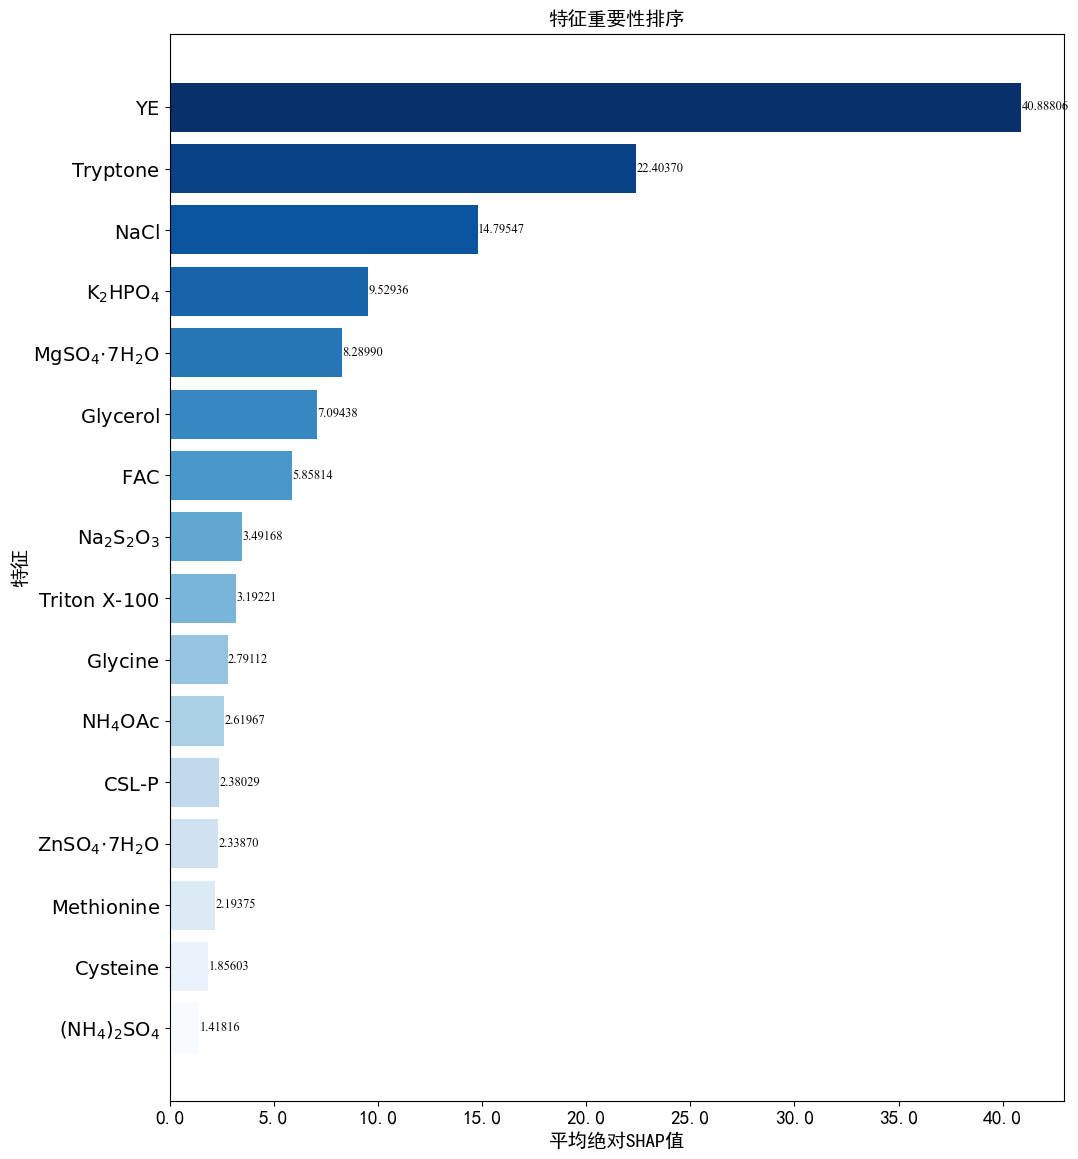

In [29]:
abs_shap_values = np.abs(shap_values)
mean_abs_shap_values = np.mean(abs_shap_values, axis=0)
sorted_indices = np.argsort(mean_abs_shap_values)[::-1]
# sorted_features = X_test.columns[sorted_indices]
sorted_mean_abs_shap_values = mean_abs_shap_values[sorted_indices]

# --- 修改点：调整图形尺寸为 8cm x 12cm ---
# 将厘米转换为英寸 (1 inch = 2.54 cm)
fig_width_cm = 28
fig_height_cm = 30
fig, ax = plt.subplots(figsize=(fig_width_cm / 2.54, fig_height_cm / 2.54))
# ----------------------------------------

# --- 1. 创建从橙色到浅蓝色的渐变色 ---
from matplotlib.colors import LinearSegmentedColormap
# start_color = '#FFB6C1'  # 橙色
# end_color = '#87ceeb'    # 浅蓝色
n_colors = len(columns)
cmap = plt.cm.Blues_r
colors = cmap(np.linspace(0, 1, n_colors))
# ------------------------------------

# --- 2. 绘制条形图 ---
bars = ax.barh(range(len(columns)), sorted_mean_abs_shap_values, align='center', color=colors)
# -------------------

# --- 3. 精细化字体和格式设置 ---
from matplotlib.font_manager import FontProperties
from matplotlib.ticker import FuncFormatter

# 定义字体
font_text = FontProperties(family='SimHei', size=14)  # 中文文字：黑体
font_num = FontProperties(family='Times New Roman', size=14) # 数字：新罗马

# 设置标题和轴标签
ax.set_title('特征重要性排序', fontproperties=font_text, fontsize=14)
ax.set_xlabel('平均绝对SHAP值', fontproperties=font_text, fontsize=14)
ax.set_ylabel('特征', fontproperties=font_text, fontsize=14)

# 设置Y轴特征名称（文字）
ax.set_yticks(range(len(columns)))
ax.set_yticklabels(columns, fontproperties=font_text)

# 设置X轴刻度（数字）为小数点后一位
def format_x_axis(x, pos):
    return f'{x:.1f}'
ax.xaxis.set_major_formatter(FuncFormatter(format_x_axis))
# 应用新罗马字体到X轴和Y轴的刻度数字
ax.tick_params(axis='x', labelsize=12, labelrotation=0)
ax.tick_params(axis='y', labelsize=12)
for label in ax.get_xticklabels():
    label.set_fontproperties(font_text)
for label in ax.get_yticklabels():
    label.set_fontproperties(font_text) # Y轴刻度标签是特征名，用黑体

# 在条形图上添加数值标签（数字用新罗马）
for i, v in enumerate(sorted_mean_abs_shap_values):
    ax.text(v + 0.01, i, f'{v:.5f}', va='center', fontproperties=font_num, fontsize=9)
# ------------------------------------

ax.invert_yaxis()
plt.tight_layout()
plt.savefig(SHAP_MAIN_OUTPUT_DIR / 'mean_absolute_shap_values.png', bbox_inches='tight')
plt.show()


### 2.4 单特征 SHAP 依赖关系与 LOESS 趋势

遍历所有特征，绘制特征取值与对应 SHAP 值的散点图，叠加 LOESS 平滑趋势线及零参考线，并分别导出 PDF。
运行前需要调整固定的Y轴范围

cross_idx: [157]


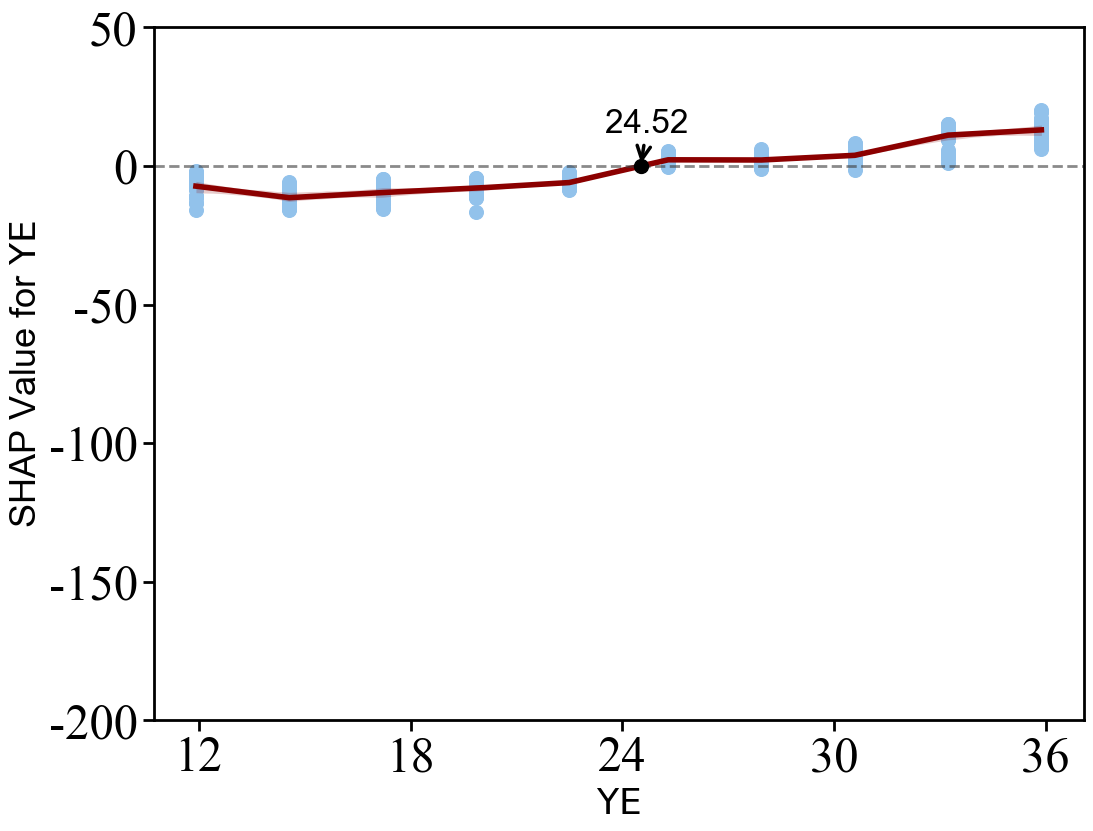

cross_idx: [98]


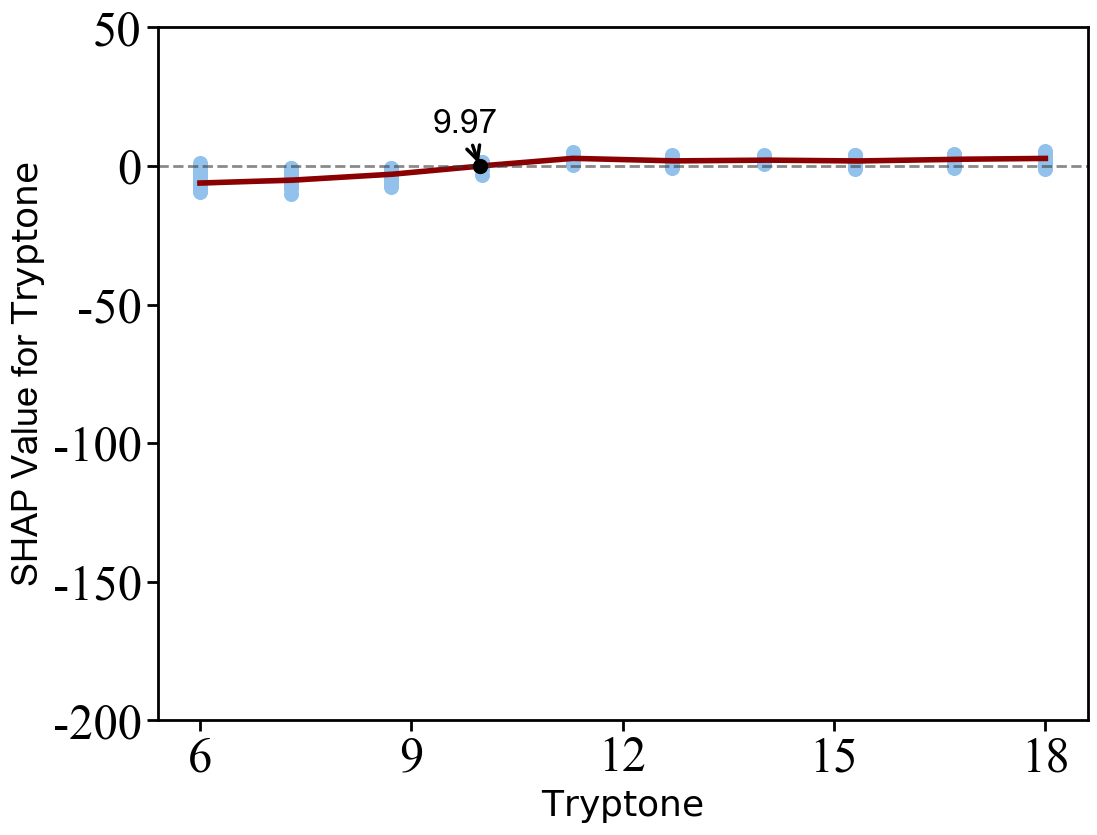

cross_idx: [ 71 254 278]


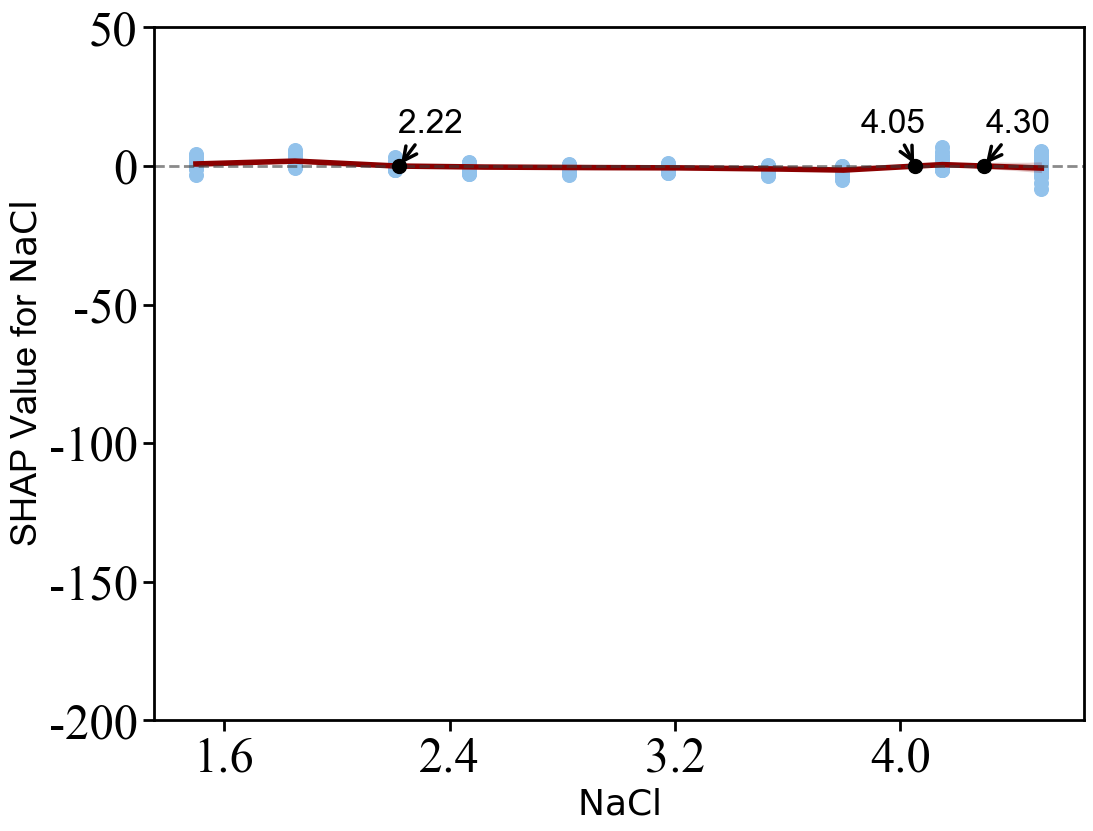

cross_idx: [106 277]


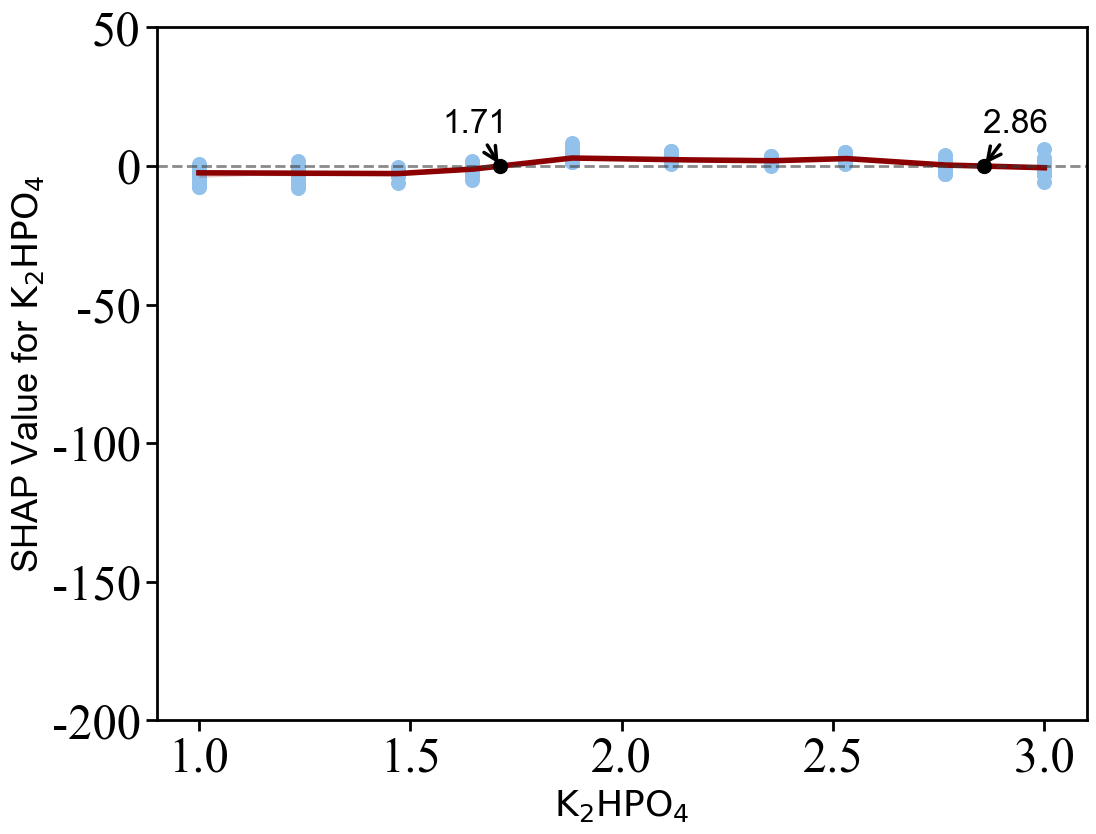

cross_idx: [ 21 197]


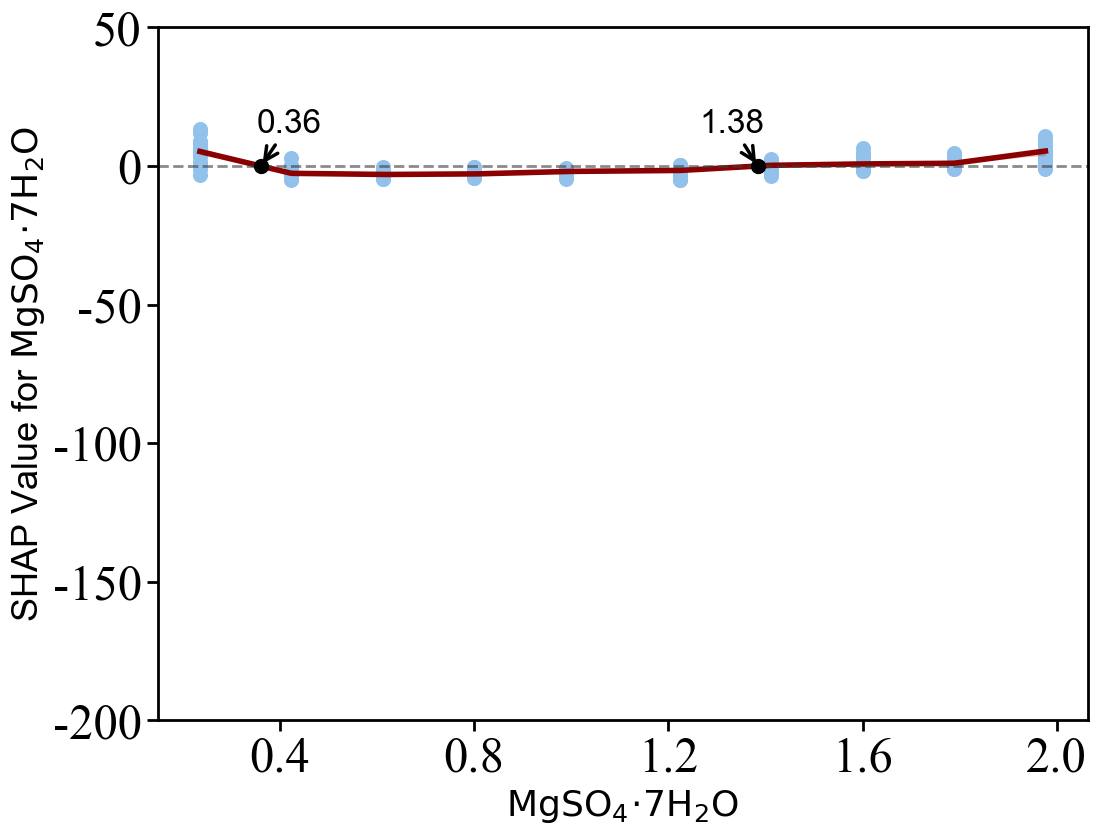

d:\apps\Anaconda\envs\learn\lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


cross_idx: [153]


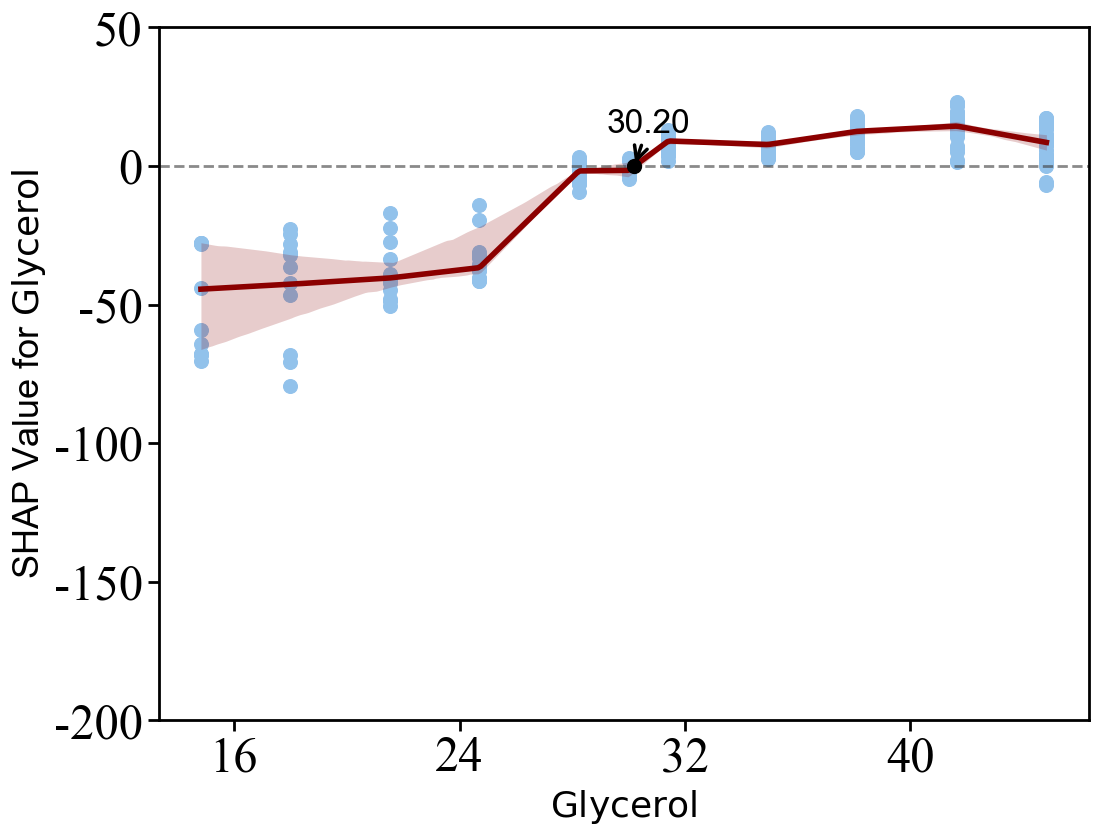

cross_idx: [ 50 238]


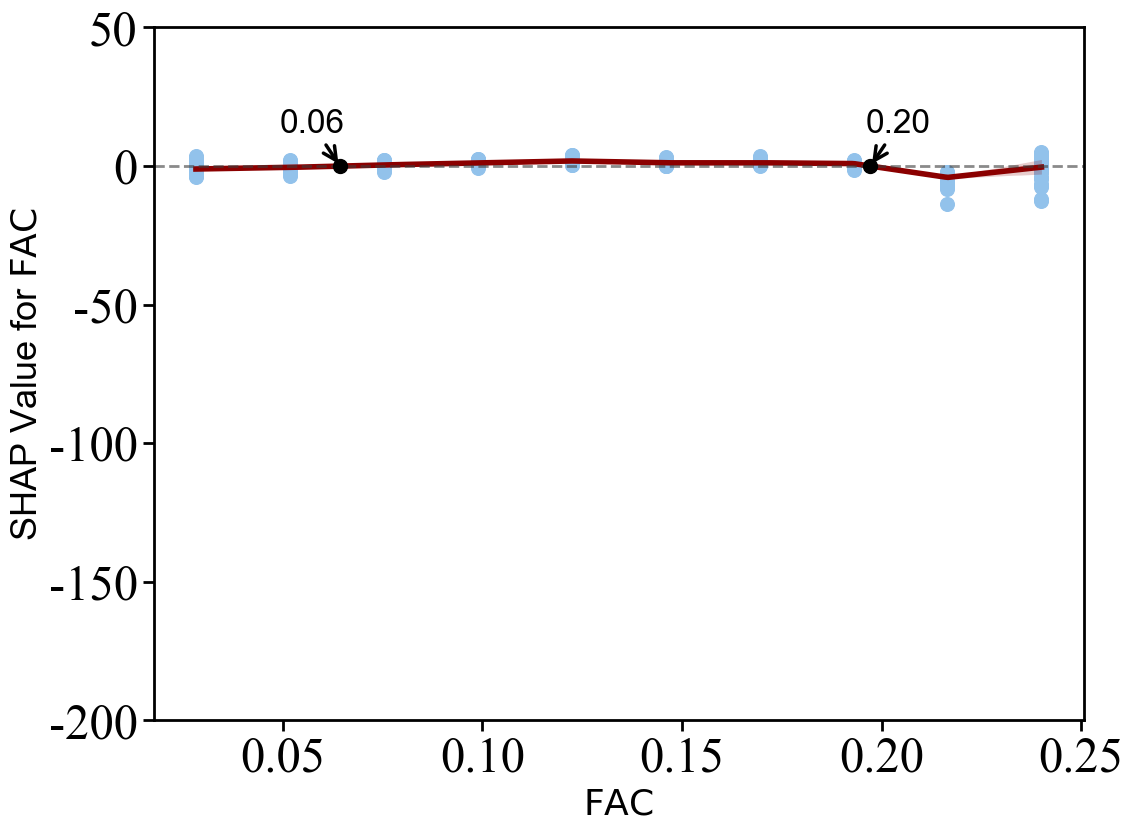

d:\apps\Anaconda\envs\learn\lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


cross_idx: [126 145 170]


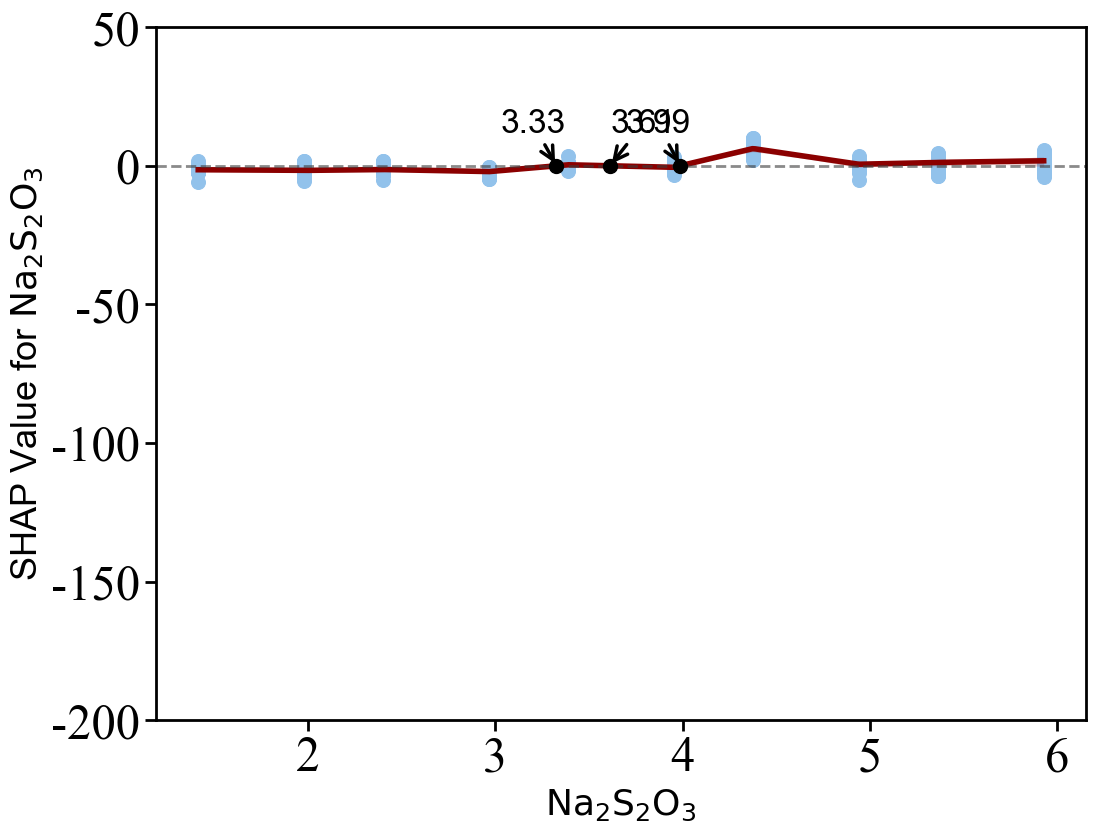

d:\apps\Anaconda\envs\learn\lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


cross_idx: [92]


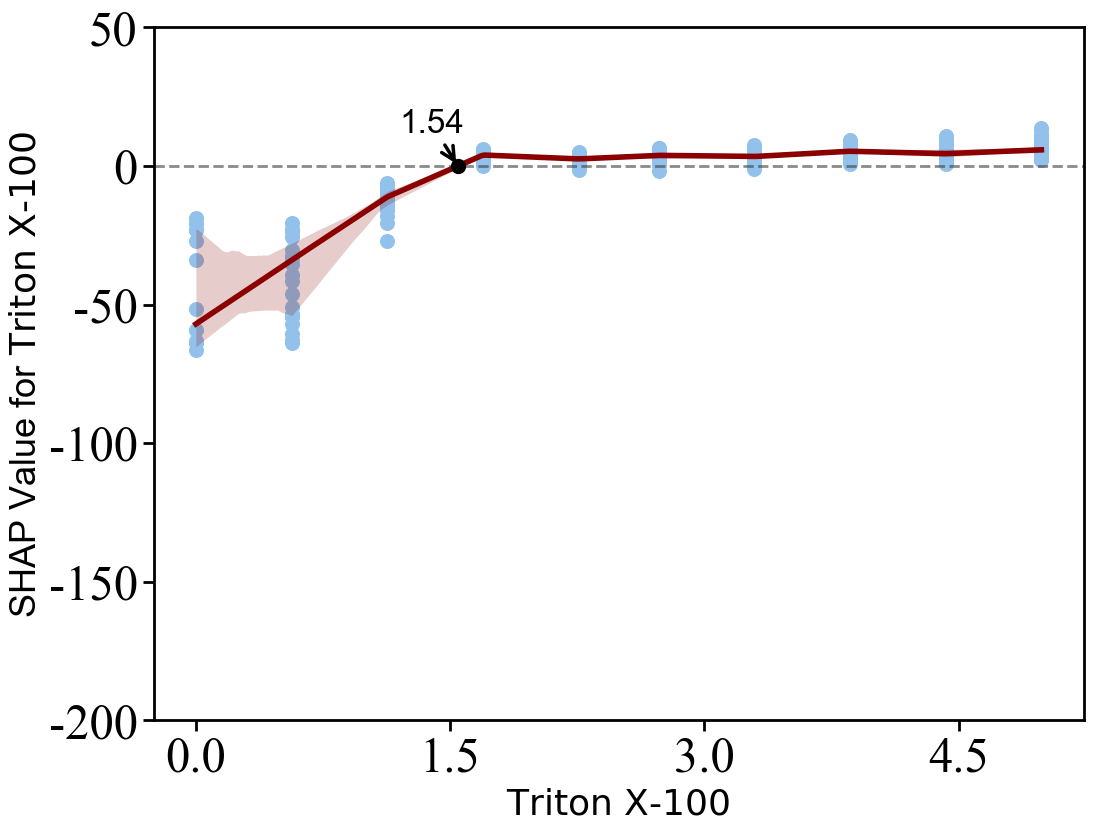

d:\apps\Anaconda\envs\learn\lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


cross_idx: [168]


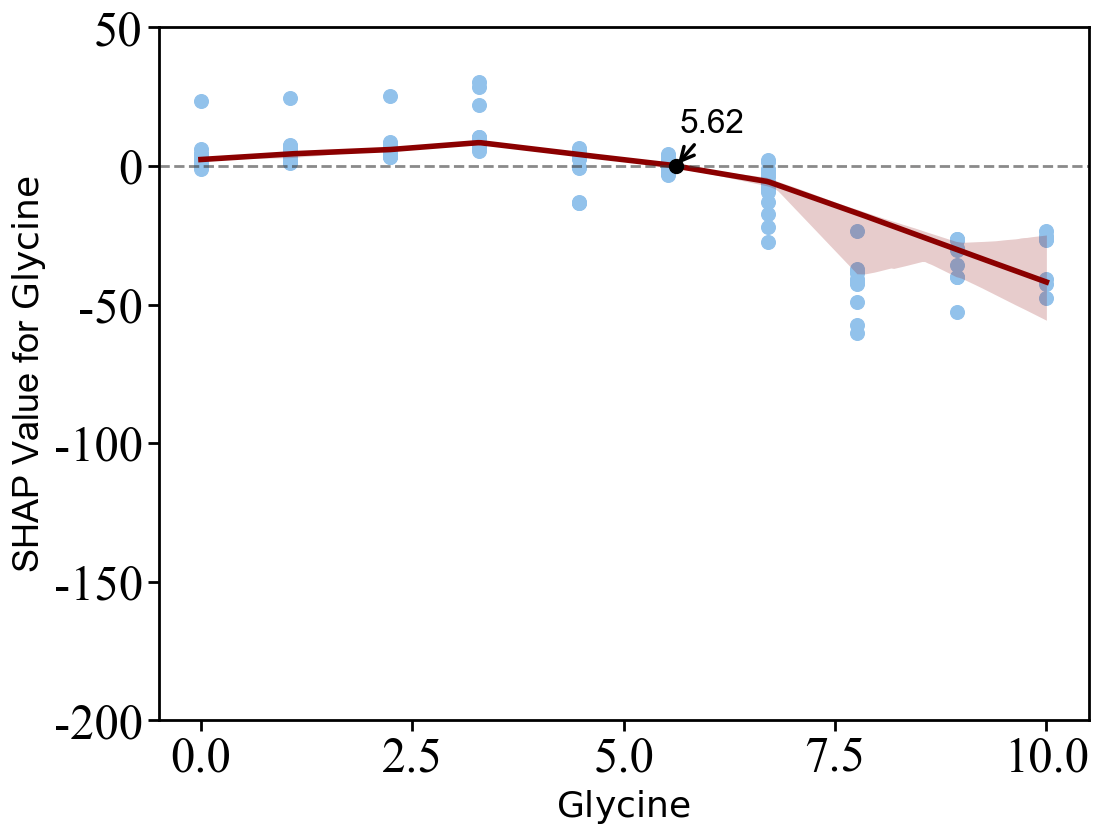

d:\apps\Anaconda\envs\learn\lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


cross_idx: [38]


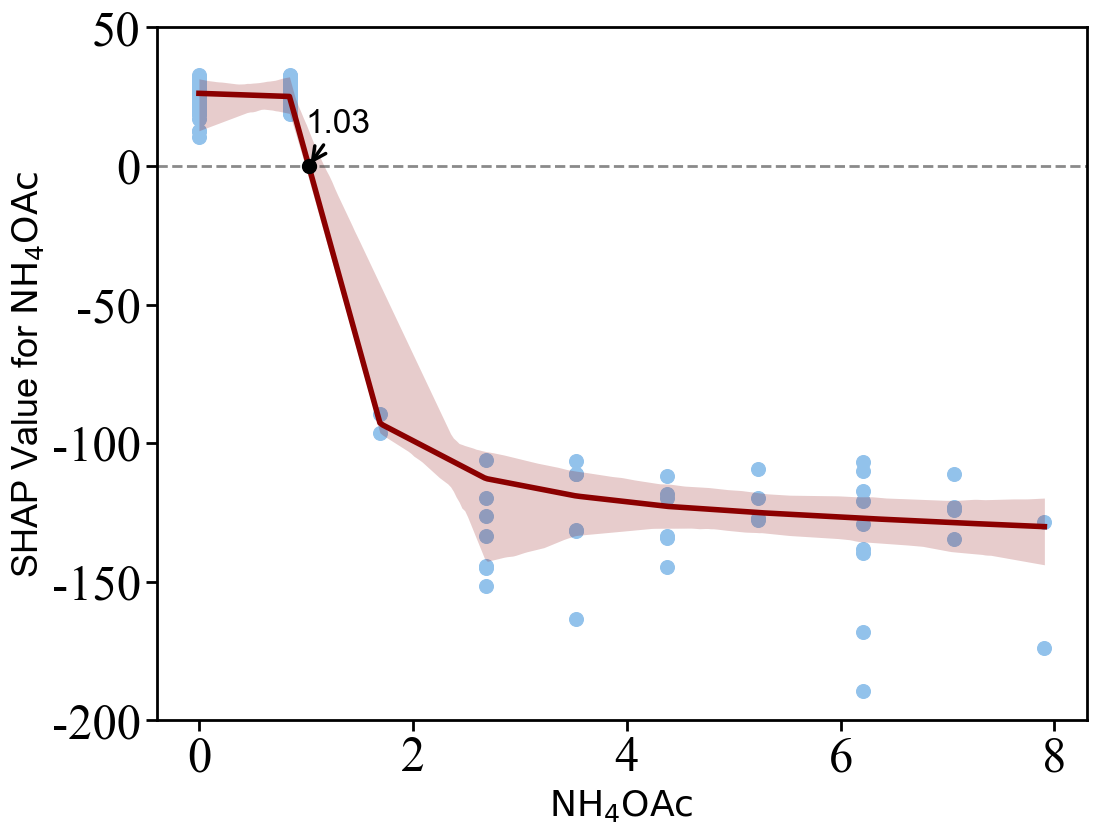

cross_idx: [181]


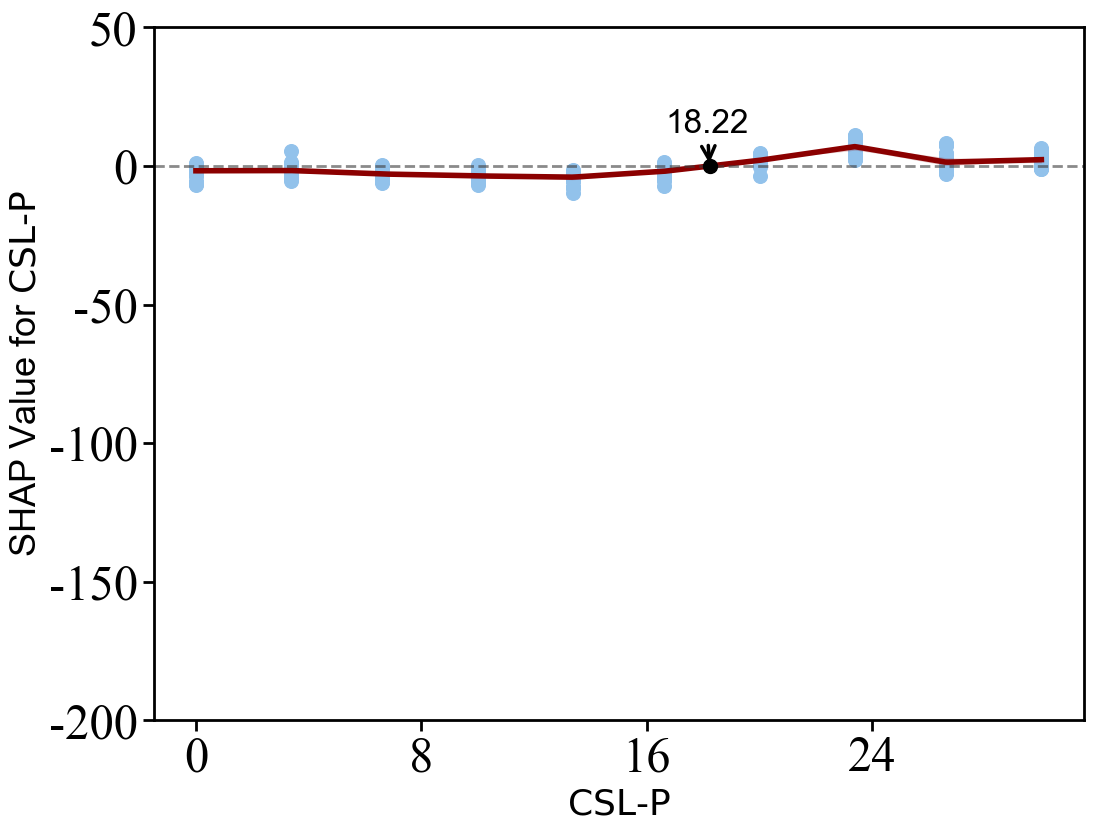

cross_idx: [138]


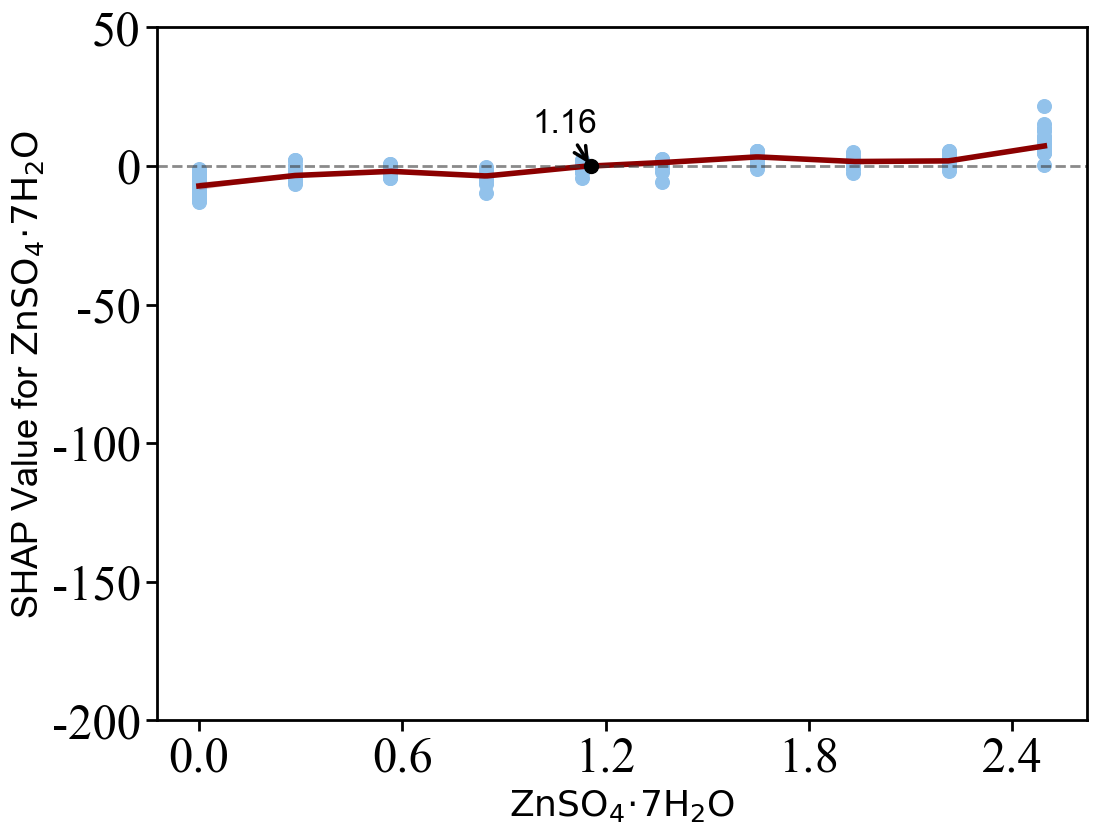

d:\apps\Anaconda\envs\learn\lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


cross_idx: [ 29 242]


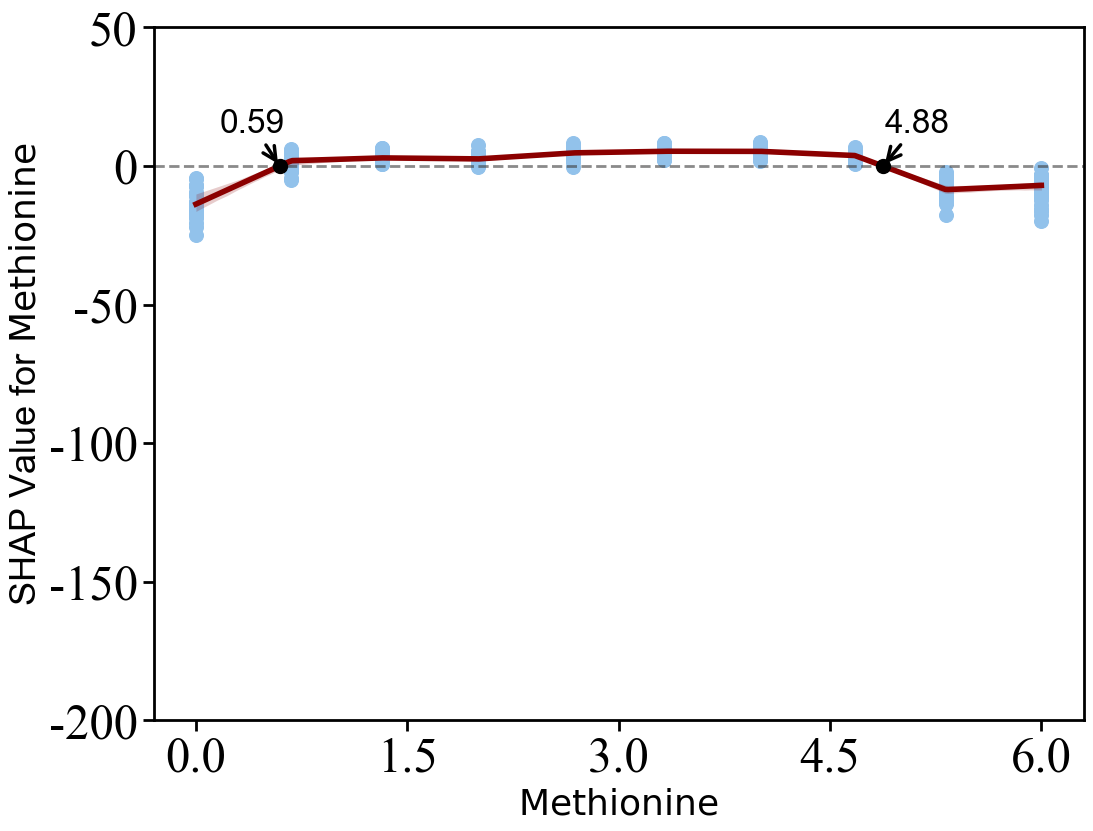

d:\apps\Anaconda\envs\learn\lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


cross_idx: [165]


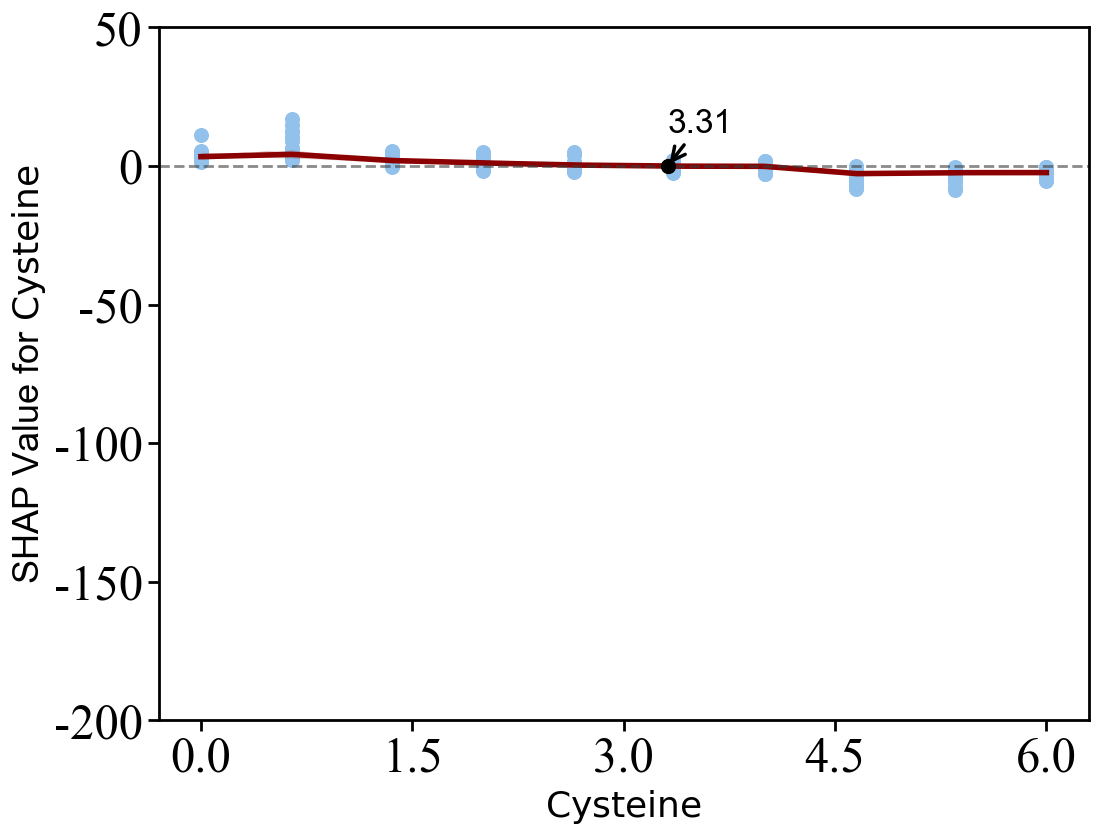

d:\apps\Anaconda\envs\learn\lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


cross_idx: [38]


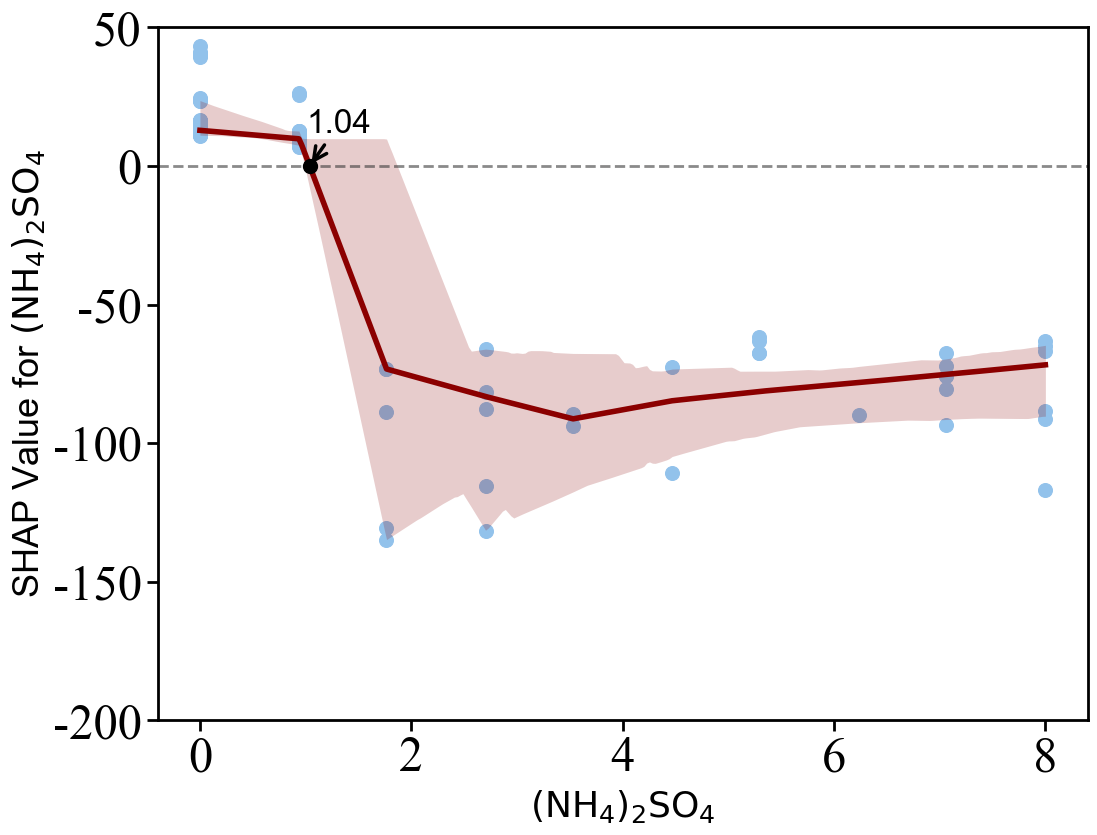

In [30]:
# SHAP 主效应超参数：本依赖关系图的 LOWESS 平滑比例。
SHAP_DEPENDENCE_LOWESS_FRAC = 0.2

from matplotlib.font_manager import FontProperties

# LOESS 置信带与坐标轴设置
LOESS_CONFIDENCE = 0.95       # 置信水平
LOESS_N_BOOTSTRAPS = 200      # bootstrap 次数；越大越稳定，但运行越慢
SHAP_DEPENDENCE_YLIM = (-200.0, 50.0)   # 在这里设置 Y 轴范围，例如：(-5, 1)

rng = np.random.default_rng(RANDOM_SEED)

for i in range(X_train.shape[1]):  # 遍历每个特征
    plt.figure(figsize=(12, 9))
    
    # 确保 SHAP 值是 NumPy 数组
    shap_array = shap_values[:, i]  # 获取第 i 个特征的 SHAP 值
    
    # 画散点图
    sns.scatterplot(x=X.iloc[:, i], y=shap_array, 
                    color='#92C2EB', edgecolor='#92C2EB', s=100)  
    
    # 去除缺失/无穷值，避免影响 LOESS 和置信带计算
    x_values = np.asarray(X.iloc[:, i], dtype=float)
    y_values = np.asarray(shap_array, dtype=float)
    valid_mask = np.isfinite(x_values) & np.isfinite(y_values)
    x_valid = x_values[valid_mask]
    y_valid = y_values[valid_mask]

    # LOESS 曲线
    # 拟合 LOESS 曲线
    loess_result = lowess(y_valid, x_valid, frac=SHAP_DEPENDENCE_LOWESS_FRAC, return_sorted=True)
    x_grid = np.linspace(x_valid.min(), x_valid.max(), 300)
    loess_line = np.interp(x_grid, loess_result[:, 0], loess_result[:, 1])
    # 绘制 LOESS 曲线
    plt.plot(x_grid, loess_line, color='#8B0000', linewidth=4, label='LOESS')


    # 设定置信带的绘制算法：'bootstrap' / 'layered_bootstrap' / 'none'
    confidence_mathod = 'bootstrap'
    if confidence_mathod != 'none':
        # 采用bootstrap方法计算置信带
        if confidence_mathod == 'bootstrap':
            bootstrap_lines = []
            for _ in range(LOESS_N_BOOTSTRAPS):
                sample_idx = rng.integers(0, len(x_valid), len(x_valid))
                boot_result = lowess(
                    y_valid[sample_idx], x_valid[sample_idx],
                    frac=SHAP_DEPENDENCE_LOWESS_FRAC, return_sorted=True
                )
                bootstrap_lines.append(np.interp(x_grid, boot_result[:, 0], boot_result[:, 1]))

            alpha = (1 - LOESS_CONFIDENCE) / 2
            ci_lower, ci_upper = np.quantile(
                np.asarray(bootstrap_lines), [alpha, 1 - alpha], axis=0
            )

        # 采用分层bootstrap方法计算置信带
        if confidence_mathod == 'layered_bootstrap' :
            bootstrap_lines = []
            unique_x = np.unique(x_valid)
            for _ in range(LOESS_N_BOOTSTRAPS):
                boot_x = []
                boot_y = []
                for xv in unique_x:
                    # 找到当前浓度水平对应的所有样本
                    mask = np.isclose(x_valid, xv)
                    x_group = x_valid[mask]
                    y_group = y_valid[mask]
                    # 在该浓度水平内部有放回抽样
                    sample_idx = rng.integers(0,len(y_group),len(y_group))

                    boot_x.extend(x_group[sample_idx])
                    boot_y.extend(y_group[sample_idx])

                boot_x = np.asarray(boot_x)
                boot_y = np.asarray(boot_y)
                # 对该次 bootstrap 数据重新拟合 LOWESS
                boot_result = lowess(boot_y,boot_x,frac=SHAP_DEPENDENCE_LOWESS_FRAC,return_sorted=True)

                # LOWESS 中可能存在重复的 x
                # 对相同 x 的拟合值取平均，便于后续插值
                boot_x_unique = np.unique(boot_result[:, 0])
                boot_y_unique = np.array([np.mean(boot_result[np.isclose(boot_result[:, 0], xv),1])
                    for xv in boot_x_unique])

                # 插值到统一的 x_grid
                boot_line = np.interp(x_grid,boot_x_unique,boot_y_unique)
                bootstrap_lines.append(boot_line)

            alpha = (1 - LOESS_CONFIDENCE) / 2
            ci_lower, ci_upper = np.quantile(
                np.asarray(bootstrap_lines),[alpha, 1 - alpha],axis=0
            )


        # 绘制置信带
        plt.fill_between(x_grid, ci_lower, ci_upper, color='#8B0000', alpha=0.20,
                            linewidth=0, label=f'{LOESS_CONFIDENCE:.0%} CI')


    # 绘制零参考线
    plt.axhline(y=0, color="#3D3C3C", linestyle='--', linewidth=2, alpha=0.6)


    # 绘制LOESS曲线与y=0的交点
    cross_idx = np.where(np.diff(np.sign(loess_line)) != 0)[0]
    print('cross_idx:', cross_idx)
    for idx in cross_idx:
        x1, x2 = x_grid[idx], x_grid[idx + 1]
        y1, y2 = loess_line[idx], loess_line[idx + 1]
        x_zero = x1 - y1 * (x2 - x1) / (y2 - y1)
        if y1-y2 >= 0 :
            xytext = (x_zero+20, 30)
        else:
            xytext = (x_zero-20, 30)
        plt.scatter(x_zero, 0, color='black', s=100, zorder=10)
        plt.annotate(f'{x_zero:.2f}', xy=(x_zero, 0), xytext=xytext,
                     textcoords='offset points', ha='center',va='center', fontsize=24,
                     arrowprops=dict(arrowstyle='->', color='black',linewidth=2.5,))   

    # 轴标签
    plt.xlabel(columns[i], fontsize=26, family='Arial')  
    plt.ylabel(f'SHAP Value for {columns[i]}', fontsize=26, family='Arial')  
    
    # 调整刻度参数
    plt.tick_params(axis='both', which='both', labelsize=34, labelcolor='black', 
                    direction='out', length=8, width=2)


    # 设置横坐标刻度个数为 5
    ax = plt.gca()
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
    if SHAP_DEPENDENCE_YLIM is not None:
        ax.set_ylim(*SHAP_DEPENDENCE_YLIM)

    # 让刻度数字的字体变大
    font_properties = FontProperties(family='Times New Roman', size=35)
    for label in plt.gca().get_xticklabels() + plt.gca().get_yticklabels():
        label.set_fontproperties(font_properties)

    # 加深边框颜色并加粗
    for spine in ax.spines.values():
        spine.set_edgecolor('black')  # 使边框变黑
        spine.set_linewidth(2)  # 增加边框厚度

    # 清除默认图例
    if ax.get_legend() is not None:
        ax.get_legend().remove()

    plt.savefig(SHAP_MAIN_OUTPUT_DIR / f'shap_dependence_plot_{safe_filename(X.columns.values[i])}.svg', bbox_inches='tight')

    # 绘图    
    plt.show()

    


   

## 3. SHAP 交互效应分析

### 3.1 计算 SHAP 交互值

利用树模型解释器计算样本层面的 SHAP 交互值张量，为分析任意两个特征之间的联合贡献提供数据。

In [31]:
shap_interaction_values = explainer.shap_interaction_values(X) 

### 3.2 SHAP 交互汇总图

绘制全部特征交互效应的 SHAP 汇总图，并将结果保存为高分辨率 PNG 文件。

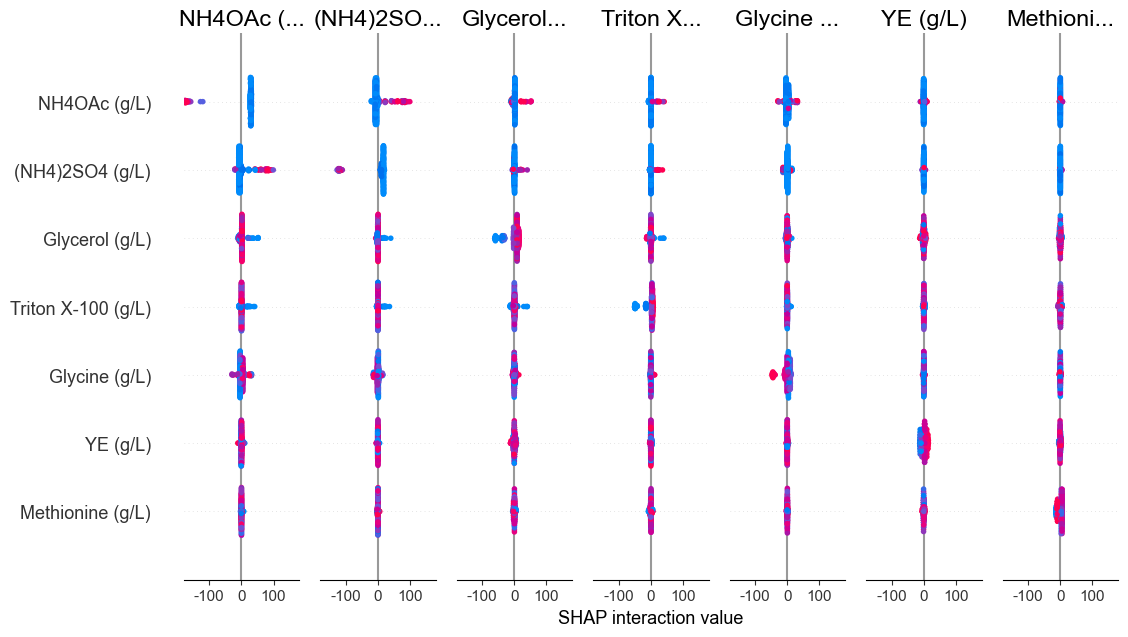

In [32]:
shap.summary_plot(shap_interaction_values, X, show=False)
plt.tight_layout()
plt.savefig(SHAP_INTERACTION_OUTPUT_DIR / 'shap_interaction_summary.png', dpi=300)
plt.show()

### 3.3 SHAP 交互矩阵

对各特征对的绝对 SHAP 交互值取样本均值，构建并可视化交互强度矩阵，同时使用统一色标便于横向比较。

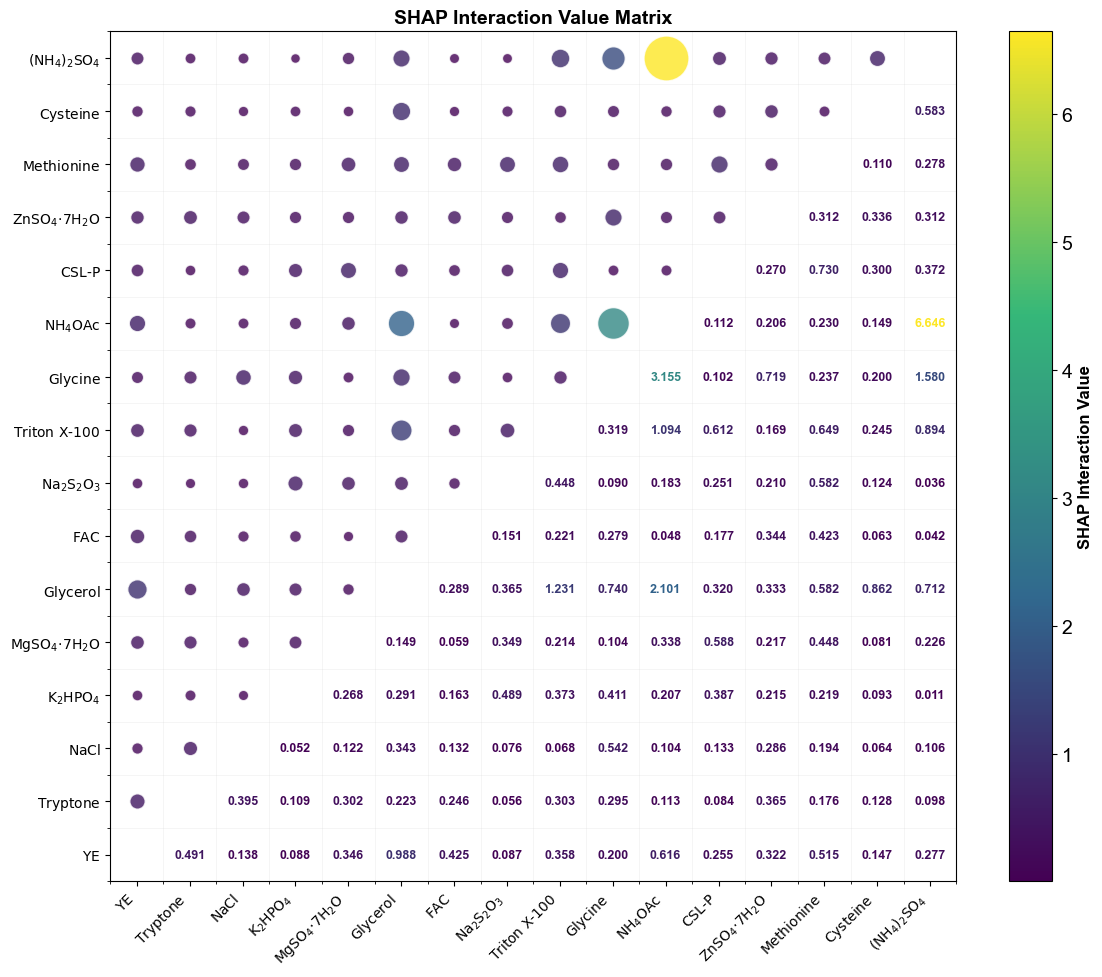

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize


feature_names = columns

# 计算SHAP交互值的平均绝对值
shap_interaction_mean = np.abs(shap_interaction_values).mean(0)

# 创建图形
fig, ax = plt.subplots(figsize=(12, 10))

# 创建颜色映射（模仿原图的颜色方案）
colors = ['#440154', '#31688e', '#35b779', '#fde725']
cmap = LinearSegmentedColormap.from_list('coolwarm', colors)

# 统一的数值归一化 - 使用整个矩阵的范围（除了对角线）
off_diagonal_mask = ~np.eye(shap_interaction_mean.shape[0], dtype=bool)
off_diagonal_values = shap_interaction_mean[off_diagonal_mask]
vmin = off_diagonal_values.min()
vmax = off_diagonal_values.max()
norm = Normalize(vmin=vmin, vmax=vmax)

n_features = len(feature_names)

# 绘制热图内容
for i in range(n_features):
    for j in range(n_features):
        value = shap_interaction_mean[i, j]
        
        if i < j:  # 上三角（主对角线上方）
            # 显示数值，字体颜色根据统一的归一化值映射
            color_intensity = norm(value)
            text_color = cmap(color_intensity)
            
            ax.text(j, i, f'{value:.3f}', 
                   ha='center', va='center', fontsize=9, 
                   color=text_color, fontweight='bold')
                   
        elif i > j:  # 下三角（主对角线下方）
            # 显示圆点，大小和颜色都根据统一的归一化值映射
            # 计算圆点大小（使用统一的归一化）
            size_factor = norm(value)
            size = size_factor * 1000 + 50  # 调整大小范围
            
            # 绘制圆点（使用统一的vmin, vmax）
            ax.scatter(j, i, s=size, c=value, 
                      cmap=cmap, alpha=0.8, 
                      edgecolors='white', linewidth=1,
                      vmin=vmin, vmax=vmax)
        # 主对角线位置 (i == j) 不绘制任何内容

# 设置坐标轴
ax.set_xlim(-0.5, n_features-0.5)
ax.set_ylim(-0.5, n_features-0.5)

# 设置刻度和标签
ax.set_xticks(range(n_features))
ax.set_xticklabels(feature_names, rotation=45, ha='right', fontsize=10)
ax.set_yticks(range(n_features))
ax.set_yticklabels(feature_names, fontsize=10)

# 添加网格线
ax.set_xticks(np.arange(-0.5, n_features, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n_features, 1), minor=True)
ax.set_title('SHAP Interaction Value Matrix', fontsize=14, fontweight='bold')
ax.grid(which='minor', color='lightgray', linestyle='-', linewidth=0.5, alpha=0.3)

# 添加颜色条 - 使用统一的归一化标准
scalar_mappable = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
scalar_mappable.set_array(off_diagonal_values)
cbar = plt.colorbar(scalar_mappable, ax=ax, shrink=1, aspect=20)
cbar.set_label('SHAP Interaction Value', fontsize=12, fontweight='bold')


plt.tight_layout()
plt.savefig(SHAP_INTERACTION_OUTPUT_DIR / 'shap_interaction_matrix.png', bbox_inches='tight')
plt.show()
